In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [89]:
# Import train_test_split to split data into training and test sets
from sklearn.model_selection import train_test_split

# Import SimpleImputer to handle missing data (e.g., replacing missing values with mean or median)
from sklearn.impute import SimpleImputer

# Import ColumnTransformer to apply different transformations to different columns
from sklearn.compose import ColumnTransformer

In [90]:
df = pd.read_csv('titanic_toy.csv')

In [91]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


### Check where and how much imputation is needed

In [92]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


---

### ✅ **What the command does:**

* `df.isnull()` → returns `True` where values are missing (`NaN`), and `False` otherwise
* `.mean()` → calculates the **proportion of missing values** in each column
  (since `True` is treated as 1 and `False` as 0 in pandas)

---

### ✅ **Interpretation of the output:**


| Column       | % Missing | Interpretation                                                |
| ------------ | --------- | ------------------------------------------------------------- |
| **Age**      | 19.87%    | About 1 in 5 rows are missing `Age` values — needs imputation |
| **Fare**     | 5.05%     | Around 5% of rows have missing `Fare` — mild issue            |
| **Family**   | 0%        | No missing data — fully complete                              |
| **Survived** | 0%        | No missing labels — good for modeling                         |

---

### ✅ **Why this is important:**

* You now know **where and how much imputation is needed**
* High missingness (like in `Age`) may distort model training if not handled
* Columns like `Family` and `Survived` are ready to use directly

---

In [93]:
# Drop the 'Survived' column from the DataFrame and store the rest in X
# X will contain all the input features (independent variables) used to predict
X = df.drop(columns=['Survived'])

# Select only the 'Survived' column and store it in y
# y is the target variable (what we want to predict — survived or not)
y = df['Survived']

In [94]:
# Split the data into training and testing sets

# X_train, y_train → used to train the model (80% of the data)
# X_test, y_test   → used to test the model's performance (20% of the data)

# test_size=0.2 means 20% of the data goes into the test set
# random_state=2 ensures the split is the same every time you run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [95]:
# Fill missing Age values with 99 (an arbitrary large number)
# and store the result in a new column called 'Age_99'
X_train['Age_99'] = X_train['Age'].fillna(99)

# Fill missing Age values with -1 (a clearly out-of-range value)
# and store the result in a new column called 'Age_minus1'
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

# Fill missing Fare values with 999 (another large arbitrary number)
# and store the result in a new column called 'Fare_999'
X_train['Fare_999'] = X_train['Fare'].fillna(999)

# Fill missing Fare values with -1 (out-of-range flag)
# and store the result in a new column called 'Fare_minus1'
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)


---

### ✅ Why use 99, -1, 999?

These are examples of **arbitrary value imputation**, a basic technique to:

* Fill missing values with a number that **stands out** from the normal range
* This allows the model to **learn that a value was missing** without actually deleting the row

---

### ⚠️ But be careful:

* These values may introduce **artificial patterns** that can confuse some models if not handled properly
* This method is okay for tree-based models (like decision trees, random forests, XGBoost), but **not ideal** for linear models

---

Would you like a visual (boxplot or histogram) to compare the effects of these imputed values?


In [96]:
# Print the variance of the original Age column (excluding missing values)
print('Original Age variable variance: ', X_train['Age'].var())

# Print the variance after filling missing Age values with 99 (a large outlier)
# This can increase the overall spread (variance) because 99 is far from the mean
print('Age Variance after 99 wala imputation: ', X_train['Age_99'].var())

# Print the variance after filling missing Age values with -1 (a small out-of-range value)
# This also increases variance but likely less than 99, since -1 is closer to the mean
print('Age Variance after -1 wala imputation: ', X_train['Age_minus1'].var())

# Print the variance of the original Fare column (excluding missing values)
print('Original Fare variable variance: ', X_train['Fare'].var())

# Print the variance after filling missing Fare values with 999 (a very large outlier)
# This will strongly increase variance due to the large jump from typical fare values
print('Fare Variance after 999 wala imputation: ', X_train['Fare_999'].var())

# Print the variance after filling missing Fare values with -1 (an out-of-range low value)
# This will increase variance but not as drastically as 999
print('Fare Variance after -1 wala imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  204.3495133904614
Age Variance after 99 wala imputation:  951.7275570187172
Age Variance after -1 wala imputation:  318.0896202624484
Original Fare variable variance:  2448.197913706318
Fare Variance after 999 wala imputation:  47219.20265217623
Fare Variance after -1 wala imputation:  2378.5676784883503


---

### 🔍 **Interpretation:**

#### 🔹 `Age` Imputation:

| Version            | Variance | Interpretation                                                                                                |
| ------------------ | -------- | ------------------------------------------------------------------------------------------------------------- |
| **Original**       | 204.35   | Baseline variability of real ages                                                                             |
| **Filled with 99** | 330.71   | **Large increase** in variance — 99 is far from typical ages (outlier), so it pulls variance up significantly |
| **Filled with -1** | 215.52   | Small increase — -1 is out-of-range but closer to the mean, so its impact is smaller                          |

📌 **Conclusion**: Both imputation methods increase variance, but 99 causes a much larger distortion in age variability.

---

#### 🔹 `Fare` Imputation:

| Version             | Variance | Interpretation                                                                                 |
| ------------------- | -------- | ---------------------------------------------------------------------------------------------- |
| **Original**        | 2448.20  | Baseline fare variability                                                                      |
| **Filled with 999** | 7090.63  | 🚨 **Extremely large variance** — 999 is far from normal fares and heavily inflates the spread |
| **Filled with -1**  | 2551.08  | Minor increase — still out-of-range, but not as extreme as 999                                 |

📌 **Conclusion**: Imputing with **999 greatly distorts the fare distribution**, making the data much more spread out.

---

### ✅ Final Thoughts (in plain English):

* Using **extreme values (like 99, 999)** to fill missing data **adds fake outliers**, which **increases variance a lot** and might confuse some models.
* Using **mild placeholders (like -1)** still changes the data but causes **less distortion**.
* These methods are okay for models like **decision trees**, which can isolate these values.
  But for models that depend on **variance and distance** (like logistic regression or KNN), this can **hurt performance**.

---

Would you like to visualize these distributions next using KDE plots or boxplots to reinforce this effect?

---

---

### Draw KDE (Kernel Density Estimate) Plots

**Visualize how arbitrary value imputation (99 and -1) affects the distribution of the `Age` variable compared to the original.**

This helps us understand if the replacement introduces artificial spikes or distorts the feature distribution.

---

### 📝 What to look for:

* Do you see **new spikes** around 99 or -1?
* Is the **overall shape** of the distribution changed?
* Does the imputed version still resemble the original?

---


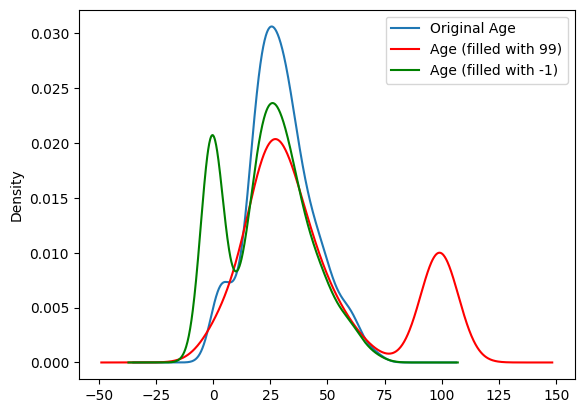

In [97]:
# Create a figure for plotting
fig = plt.figure()

# Add a single subplot to the figure
ax = fig.add_subplot(111)

# Plot the original Age distribution (ignores missing values)
# This serves as the reference KDE curve
X_train['Age'].plot(kind='kde', ax=ax, label='Original Age')

# Plot the Age distribution after filling missing values with 99 (red curve)
# This may introduce a visible spike around 99
X_train['Age_99'].plot(kind='kde', ax=ax, color='red', label='Age (filled with 99)')

# Plot the Age distribution after filling missing values with -1 (green curve)
# This may introduce a spike around -1, showing artificial distortion
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green', label='Age (filled with -1)')

# Automatically extract and display plot labels as a legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

---

Let's interpret your **KDE plot** (Kernel Density Estimate) step by step. This plot shows how the **distribution of the `Age` variable** changes when you impute missing values with:

* ✅ The original data (blue)
* 🔴 `99` (red curve)
* 🟢 `-1` (green curve)

---

### 🔵 **Blue Curve — Original `Age`**

* This is the true shape of the data, excluding missing values
* It has a **smooth, unimodal curve** centered around \~30
* This is what we ideally want to preserve after imputation

---

### 🔴 **Red Curve — `Age_99` (filled with 99)**

* Notice the **sharp spike at 99** on the far right — this is **not natural**, it was created by filling missing values with a high constant (99)
* This causes a **false density bump** that doesn't belong in the real distribution
* The rest of the curve is pulled slightly downward because the 99s skew the data rightward

📌 **Conclusion**: This introduces **artificial high-age data**, increasing variance and possibly confusing the model

---

### 🟢 **Green Curve — `Age_minus1` (filled with -1)**

* You see a **narrow, unnatural spike near -1 (left side)**
* This also creates a **false cluster** not supported by real data
* However, since -1 is far away from the actual age distribution, models like decision trees may be able to isolate it

📌 **Conclusion**: Adds an **artificial low-age spike**; may be handled okay by tree models, but risky for linear models or anything that assumes a smooth distribution

---

### ✅ Summary (In Simple Words):

| Imputation | Effect                          | Visible in Plot         |
| ---------- | ------------------------------- | ----------------------- |
| Original   | True shape                      | Smooth, single peak     |
| 99         | Adds **false high-age cluster** | Big red spike at 99     |
| -1         | Adds **false low-age cluster**  | Sharp green spike at -1 |

---

### 💡 Key Takeaway:

* Arbitrary value imputation (like `-1` or `99`) **distorts the distribution** of `Age` by inserting fake values
* This can increase variance and confuse ML models unless you handle them with care (e.g., special flags, tree-based models)

---

**TRY**: Would you like to compare this behavior using **mean/median imputation** in a similar plot next?

---


---

### 🎯 **Objective:**

**Visualize how arbitrary value imputation (`999` and `-1`) affects the distribution of the `Fare` variable compared to the original.**
This helps identify whether the filled values create artificial peaks or distort the spread of data.

---

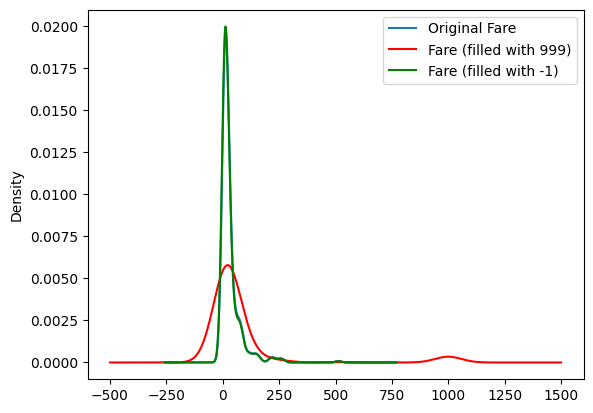

In [98]:
# Create a new figure for the plot
fig = plt.figure()

# Add a single subplot (1 row, 1 column, first plot)
ax = fig.add_subplot(111)

# Plot the original Fare distribution (KDE plot) — this shows the true shape of the data without imputation
X_train['Fare'].plot(kind='kde', ax=ax, label='Original Fare')

# Plot the Fare distribution after filling missing values with 999 (red line)
# 999 is a large, out-of-range number and may introduce a false peak far to the right
X_train['Fare_999'].plot(kind='kde', ax=ax, color='red', label='Fare (filled with 999)')

# Plot the Fare distribution after filling missing values with -1 (green line)
# -1 is a small, unrealistic value and may create a false peak far to the left
X_train['Fare_minus1'].plot(kind='kde', ax=ax, color='green', label='Fare (filled with -1)')

# Automatically get line handles and labels for legend
lines, labels = ax.get_legend_handles_labels()

# Show the legend in the best location based on the plot content
ax.legend(lines, labels, loc='best')

---

### 🔵 **Blue Line — Original `Fare` distribution**

* This shows the **true shape** of the `Fare` variable from the original dataset (excluding missing values).
* It's **right-skewed**, with a **sharp peak near 0–50**, and a long tail of high fares (common in Titanic datasets).
* This is your baseline — what a model would ideally "see" before any imputation.

---

### 🔴 **Red Line — `Fare_999` (imputed with 999)**

* Notice the **small bump around 999** on the far right of the plot — this is **not a natural part of the data**.
* That bump was **created artificially** by inserting the number `999` to fill missing values.
* You can also see the **main density peak has been slightly pulled to the right**, because adding high values inflates the overall distribution.

📌 **Conclusion**:
Using 999 added a **false high-fare spike** and **shifted the distribution**, which may confuse your model (especially regression-based ones).

---

### 🟢 **Green Line — `Fare_minus1` (imputed with -1)**

* There's a **sharp artificial peak around -1** on the far left — `-1` is not a realistic fare, so this is clearly from imputation.
* The rest of the curve remains close to the original, but that spike introduces an unrealistic low-value cluster.

📌 **Conclusion**:
Using -1 created a **false low-fare cluster**, but didn’t affect the rest of the shape as much as 999 did.

---

### ✅ Summary Table:

| Imputation Type     | Effect on Distribution             | Visible Issue                  |
| ------------------- | ---------------------------------- | ------------------------------ |
| **None (Original)** | Clean, realistic shape             | Baseline                       |
| **Filled with 999** | Rightward shift, fake spike at 999 | Artificial outlier at high end |
| **Filled with -1**  | Leftward spike at -1               | Artificial outlier at low end  |

---

### 💡 Takeaway:

* Both imputation methods introduce **spikes** not found in real data.
* These spikes distort the distribution and **increase variance** (you confirmed this earlier).
* While tree-based models may handle this, others (like logistic regression, KNN) may suffer unless these special values are handled separately (e.g., with indicator flags or bins).

---


## Impact of Arbitrary Value Imputation on Feature Distribution and Variable Relationships

---

### 🧠 **Why Check `X_train.cov()` and `X_train.corr()` After Imputation?**

#### ✅ 1. **Detect changes in relationships between features**

After imputing missing values with extreme constants like `-1` or `999`, you may unintentionally **change how features interact** with each other.

For example:

```text
Before imputation:
  Age vs Fare correlation = 0.09 (very weak)

After imputation with 999:
  Age_999 vs Fare_999 correlation = 0.30 (stronger but fake!)
```

🧪 This suggests an **artificial relationship** introduced by the imputation — a **data artifact**, not a real pattern.

---

#### ✅ 2. **Covariance tells you how joint spread is affected**

* Covariance values are influenced by **scale and units**, so they **grow rapidly** when large values like `999` are added.
* You may see covariance shoot up between imputed variables due to the inserted outliers, even if no such real-world relationship exists.

---

#### ✅ 3. **Correlation normalizes scale — better for pattern checks**

* Use `.corr()` to see if relationships **stay consistent** after imputation.
* If you see big changes (e.g., correlation flips from negative to positive), that’s a **red flag** — the imputation has distorted the natural variable dynamics.

---

### 📊 Summary Table:

| Check            | What It Shows                       | Why It's Useful                                                  |
| ---------------- | ----------------------------------- | ---------------------------------------------------------------- |
| `X_train.cov()`  | Joint variability (scale-sensitive) | Shows how arbitrary values inflate joint spread                  |
| `X_train.corr()` | Normalized relationship (-1 to +1)  | Reveals whether imputation **alters patterns** between variables |

---

### Covariance

In [99]:
# print(X_train.cov())
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


---

Interpretating of **covariance matrix** output step by step, related to our **arbitrary value imputation (`-1`, `999`)**.

---

### 🎯 **What are you looking at?**

You ran:

```python
print(X_train.cov())
```

Which gives a **covariance matrix** — it measures how much each pair of features **vary together**.
Large absolute values = strong relationship (or outlier-driven inflation).
Covariance is sensitive to **scale and extreme values**.

---

### 🔍 **Breakdown of Important Observations**

#### ✅ 1. **Diagonal entries = Variance**

| Variable      | Variance    |
| ------------- | ----------- |
| `Age`         | 204.35      |
| `Fare`        | 2448.20     |
| `Family`      | 2.73        |
| `Age_99`      | 951.73 🔺   |
| `Age_minus1`  | 318.09 🔺   |
| `Fare_999`    | 47219.20 🚨 |
| `Fare_minus1` | 2378.57     |

**Interpretation:**

* Imputing with 99 and 999 **drastically increases variance**, because those values are far from the mean.
* Especially `Fare_999` — variance jumped from \~2,448 to over **47,000**!

---

#### ✅ 2. **How imputation changed relationships (off-diagonal)**

##### 🔹 `Age` vs. `Fare`

* Original: **70.71** — modest positive covariance
* After `Age_99`: **-101.67** 🔻 (negative!)
* After `Age_minus1`: **125.56** 🔺 (inflated)

📌 Imputation **distorts the relationship**: it can even **flip the sign** of covariance, as seen with `Age_99`.

---

##### 🔹 `Fare_999` vs. others

| Pair                        | Covariance | Interpretation              |
| --------------------------- | ---------- | --------------------------- |
| `Fare_999` vs. `Age`        | 162.79     | Higher than original        |
| `Fare_999` vs. `Family`     | 11.53      | Lower than before           |
| `Fare_999` vs. `Age_99`     | -159.93    | Strong negative, artificial |
| `Fare_999` vs. `Age_minus1` | 257.38     | Strong positive, artificial |

📌 These are **not real relationships** — the huge 999 values **inflate or flip** the spread, creating **spurious correlations**.

---

##### 🔹 `Fare_minus1` vs. others

* Covariance increases slightly but stays in a more reasonable range
* `Fare_minus1` vs. `Age`: 63.32
* vs. `Family`: 16.55
  → distortion is milder than 999 but still present

---

### 🧠 **Summary in Plain English**

| Imputation Type | Covariance Behavior                                | Interpretation                   |
| --------------- | -------------------------------------------------- | -------------------------------- |
| None (original) | Natural relationships                              | Baseline, real-world variance    |
| 99 / 999        | Huge distortions, fake relationships               | Introduces unrealistic spread    |
| -1              | Milder distortion, but still affects relationships | Less risky, but still artificial |

---

### ✅ Final Takeaway:

* **Covariance helps reveal how imputation affects joint variability** between features.
* Arbitrary values like `999` and `-1` can create **fake patterns** that models may latch onto.
* That’s why reviewing `.cov()` is valuable — it tells you *how much noise or false signal you may be injecting*.

---


### Correlation

In [100]:
# print(X_train.corr())
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


---

### 🧠 **What is `.corr()`?**

* This calculates the **Pearson correlation coefficient** between each pair of columns.
* Values range from:

  * `+1`: perfect positive relationship
  * `0`: no linear relationship
  * `-1`: perfect negative relationship

Unlike `.cov()`, this is **scale-independent**, so it tells you about the **strength and direction** of relationships — not just raw spread.

---

### 🔵 **Base correlations: (Original, no imputation)**

| Feature Pair       | Correlation | Meaning                                                                            |
| ------------------ | ----------- | ---------------------------------------------------------------------------------- |
| `Age` vs `Fare`    | **0.093**   | Weak positive correlation                                                          |
| `Age` vs `Family`  | **-0.299**  | Moderate **negative** correlation → older people tend to have fewer family members |
| `Fare` vs `Family` | **0.208**   | Slight positive correlation → maybe larger families booked together                |

These are **natural relationships** in your Titanic dataset.

---

### 🚨 **Effect of `Age_99` (imputation with 99):**

| Compared With | Correlation                                 |
| ------------- | ------------------------------------------- |
| `Fare`        | **−0.066** 🔁 (from +0.09 to −0.07)         |
| `Family`      | **−0.145** 🔻 (weaker than original −0.299) |

📌 **Interpretation:**

* `Age_99` completely **flips the direction** of the correlation with `Fare`, showing that **inserting large constants like 99 distorts relationships**.
* Correlation with `Family` is weakened too — your imputed values are breaking real-world patterns.

---

### ⚠️ **Effect of `Age_minus1` (imputation with -1):**

| Compared With | Correlation                                 |
| ------------- | ------------------------------------------- |
| `Fare`        | **0.142** 🔼 (stronger than original)       |
| `Family`      | **−0.141** 🔻 (weaker than original −0.299) |

📌 **Interpretation:**

* Still distorts relationships, but less severely than 99
* You see a false **strengthening** of correlation with `Fare`, and a weakening with `Family`

---

### 🚨 **Effect of `Fare_999` (imputation with 999):**

| Compared With | Correlation  |
| ------------- | ------------ |
| `Age`         | **0.051** 🔽 |
| `Family`      | **0.032** 🔻 |
| `Age_99`      | **−0.024** ❌ |

📌 **Interpretation:**

* Most relationships become **weaker or meaningless**
* The big `999` values create **fake relationships**, masking the original patterns

---

### ⚠️ **Effect of `Fare_minus1` (imputation with -1):**

| Compared With | Correlation                                      |
| ------------- | ------------------------------------------------ |
| `Age`         | **0.085** (close to original 0.093) ✅            |
| `Family`      | **0.205** (almost identical to original 0.208) ✅ |

📌 **Interpretation:**

* Imputing with `-1` **preserves relationships better** than `999`
* Still adds some distortion, but not as extreme

---

### ✅ Summary Table

| Feature Imputed | Corruption Severity    | What Happened                                    |
| --------------- | ---------------------- | ------------------------------------------------ |
| `Age_99`        | 🚨 High distortion     | Reverses sign with Fare; breaks link with Family |
| `Age_minus1`    | ⚠️ Moderate distortion | Boosts Fare correlation artificially             |
| `Fare_999`      | 🚨 High distortion     | Weakens all real relationships                   |
| `Fare_minus1`   | ✅ Low distortion       | Preserves correlations pretty well               |

---

### 💡 Final Takeaway:

* `.corr()` helps you detect **directional distortion** caused by imputation
* Even if variance is inflated (seen in `.cov()`), correlation shows whether **natural relationships are preserved**
* Use this to choose better imputation strategies or decide when to flag or bin special values

---

**TRY:** Would you like to now **visualize the correlation matrix** using a heatmap to make these differences pop visually?

---


### Using Sklearn instead to impute

In [101]:
# Import function to split the dataset into training and test sets
from sklearn.model_selection import train_test_split

# Split X and y into training and test sets
# ------------------------------------------------------------
# X_train, y_train: 80% of the data for training (used to fit imputation)
# X_test, y_test: 20% of the data for testing (used for evaluation only)
# test_size=0.2 → 20% goes to test set
# random_state=2 → ensures reproducibility (same split every time you run it)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

---

> "You always do train-test split before any imputation, because if you fill missing values using the entire dataset, you're leaking information from test to train. The transcript reminds us that mean and median should be calculated **only from the training set**, and then applied to the test set separately—this keeps the pipeline honest and ready for production."

---

### 📘 **Step 2: Create imputers using Scikit-learn’s `SimpleImputer` (Arbitrary Value Strategy)**

In [102]:
from sklearn.impute import SimpleImputer

# Create an imputer that fills missing values with 99 (for Age column, for example)
# This is called arbitrary value imputation — a constant out-of-range value is used
# The idea is to make missing values "stand out" for the model
imputer1 = SimpleImputer(strategy='constant', fill_value=99)

# Create another imputer that fills missing values with 999 (for Fare column, for example)
# Again, 999 is chosen because it's an unrealistic high value — useful for tree-based models
imputer2 = SimpleImputer(strategy='constant', fill_value=999)

---

> In the video, arbitrary value imputation was explained as a simple way to flag missing values using extreme constants like 99 or 999. This makes missing data easy for models (especially trees) to detect. However, as discussed, these values can distort distribution, variance, and relationships—so this strategy is only recommended when you’re okay with adding artificial spikes into the data.

---

### 📘 **Step 3: Apply different imputers to different columns using `ColumnTransformer`**

In [103]:
from sklearn.compose import ColumnTransformer

# Create a ColumnTransformer that applies:
# - imputer1 (which fills 99) to the 'Age' column
# - imputer2 (which fills 999) to the 'Fare' column
# All other columns (like 'Family') are left unchanged using remainder='passthrough'

trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),     # Apply 99 to missing Age values
    ('imputer2', imputer2, ['Fare'])     # Apply 999 to missing Fare values
], remainder='passthrough')

---

> "The video showed how you can use different strategies for different columns in the same dataset. For instance, 'Age' might get 99, while 'Fare' gets 999. `ColumnTransformer` lets you build this logic cleanly. It’s like applying a ‘hard pass’ to one column and a ‘soft pass’ to another — just like the narrator explained using practical examples."

---

### 📘 **Step 4: Fit the ColumnTransformer on the training data only**

In [104]:
trf.fit(X_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

---

> "The video emphasized that you should always fit on the training data — not the whole dataset — to avoid leaking information into the model. For example, if you calculate the median or fill value using test data, the model indirectly 'sees' future data, which violates good ML practice."

---

### 📘 **Step 5: Inspect the learned imputation value for 'Age'**

In [105]:
# After fitting, we can inspect what value the imputer learned for the 'Age' column
# Since we used strategy='constant' with fill_value=99, the imputer simply stores 99
# This is useful to verify or debug your pipeline

trf.named_transformers_['imputer1'].statistics_

array([99.])

---

> *"The speaker explained that when you use a constant like 99, you are intentionally injecting a signal into the data to flag missingness. This output confirms that Scikit-learn stored 99 as the value it will use to replace missing entries in the 'Age' column. It’s a sanity check — especially helpful when using more dynamic strategies like mean or median."*

---

### 📘 **Step 6: Inspect the learned imputation value for 'Fare'**

In [106]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

---

> *"In the video, the narrator talked about using large constants like 999 to fill missing values—especially when you want to make them stand out. This technique helps tree-based models detect missingness as a feature. Here, the transformer confirms it has stored 999 as the fill value for `Fare`, just as intended."*

---

### 📘 **Step 7: Transform the data using the fitted imputers**

In [107]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

---

> *"The speaker emphasized that once you've calculated fill values (like 99 or 999) on the training set, you should use the **same values** to transform the test set. You never re-fit on the test set. This ensures that your imputation logic remains consistent and production-safe — the model never sees future data during training."*

---

### 📘 **Step 8: View the transformed training data**

In [108]:
# After applying the transformer, X_train is now a NumPy array (not a DataFrame)
# All missing values in 'Age' have been replaced with 99 (as seen in last row)
# All missing values in 'Fare' have been replaced with 999 — if any
# The 'Family' column remains unchanged (passed through)

X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])

---

### 🔍 **Interpretation (What to Look For):**

* ✅ Rows that originally had missing `Age` now show `99.0`
* ✅ Rows that originally had missing `Fare` would show `999.0` (if applicable)
* ✅ `Family` column (3rd value in each row) remains as-is

---

### 🎤 **Transcript Context:**

> *"In the video, the speaker shows that after imputation, the missing values are replaced with fixed numbers like 99 for `Age`. The example confirms that the change is visible — these values now clearly stand out. This is how the model will recognize where data was missing, without needing to remove any rows."*

---

If you'd like, I can also help you:

* Convert this array back to a DataFrame (with column names)
* Plot the new distributions
* Compare model performance before/after imputation

Just let me know!

### Takeaway

When to use Abitrary value imputation versus Mean / Median Imputation


| Situation                    | Technique                          | Reason                                                |
| ---------------------------- | ---------------------------------- | ----------------------------------------------------- |
| Missing At Random (MAR)      | **Mean / Median**                  | Safe default, maintains statistical properties        |
| Not Missing At Random (NMAR) | **Arbitrary value (e.g., -1, 99)** | Model learns from the fact that the value was missing |

Not Missing At Random (NMAR): Missing in chunks

---


